In [1]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=ada1b946e2b0527a659041a9869f75b8902b79af096995d1bbdedd95c0d596e5
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


In [2]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd
import numpy as np
from nltk.tokenize import word_tokenize
import nltk

import re
import nltk
from nltk import WordNetLemmatizer
from langdetect import detect
from nltk.corpus import opinion_lexicon
from nltk import word_tokenize

In [4]:
news = pd.read_csv("/content/drive/MyDrive/fake_real_news.csv")

In [5]:
# Combine title and text
news['text_final'] = news['title'] + '... ' + news['text']

# Drop unnecessary columns
df = news.drop(columns=['title', 'text', 'idd'])

# Binary encode labels: FAKE = 1, REAL = 0
df['label'] = df['label'].apply(lambda x: 1 if x == 'FAKE' else 0)

# Force text_final to string
df['text_final'] = df['text_final'].astype(str)

# Detect language and filter only English
languages = []
for sentence in df['text_final']:
    languages.append(detect(sentence))
df['language'] = languages
df = df[df['language'] == 'en']

In [6]:
# Load the multilingual news topic classifier
model_name = "classla/multilingual-IPTC-news-topic-classifier"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.79k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

In [7]:
def classify_topic(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = softmax(logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()
    return pred

In [8]:
# Apply classification to a sample (for speed)
df_sample = df.sample(n=4000, random_state=42).copy()
df_sample['topic_id'] = df_sample['text_final'].apply(classify_topic)


In [9]:
# Get label mapping
labels = model.config.id2label
df_sample['topic'] = df_sample['topic_id'].map(labels)

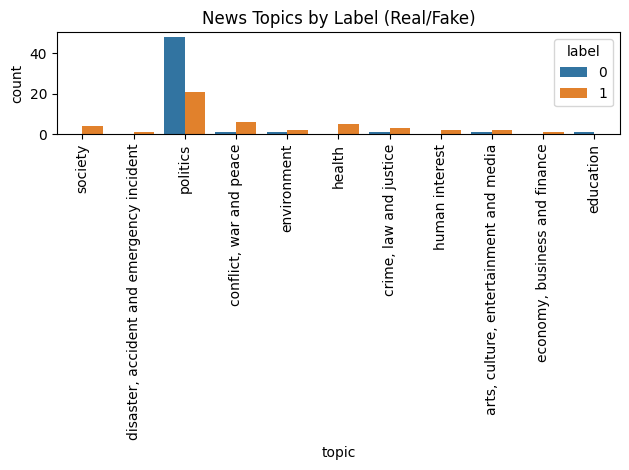

In [10]:
# Analyze topic distribution by label (real or fake)
sns.countplot(data=df_sample, x='topic', hue='label')
plt.title('News Topics by Label (Real/Fake)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [12]:
# Save annotated sample to CSV
df_sample.to_csv('news_with_topics_sample.csv', index=False)